In [1]:
import torch

from src import model as models

## importamos los dataloaders
from src.datadogs import dog_train_loader, dog_test_loader

from src.utils import probar_modelo, comparar_modelos, calculo_perdida

from src.train import train_ae, train_metanca


In [2]:
# Configuración de hardware acelerado
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Usando el dispositivo: {device}")

## para que los cambios en los files se apliquen sin reiniciar kernels
%load_ext autoreload
%autoreload 2

Usando el dispositivo: cuda


In [4]:
### USados en V1

# 1. Configuración de Canales (Flujo Simétrico de Dimensiones)
CHANNELS_IN       = 3   # Imágenes RGB de entrada
CHANNELS_LEVEL_1  = 64  # Resolución alta (Skip Connection c1_out / d2_out)
CHANNELS_LEVEL_2  = 128  # Resolución intermedia (Salida de compresión y Pass-Through)
CHANNELS_LATENT   = 32  # Cuello de botella latente (Espacio del ADN / Entrada del NCA)
CHANNELS_OUT      = 3   # Clases del Trimapa (Fondo, Interior, Contorno)

# 2. Parámetros de Convolución Estándar
KERNEL_STD        = 3
STRIDE_NORMAL     = 1
STRIDE_COMPRESS   = 2
PADDING_STD       = 1

# 3. Regularización y Normalización
DROPOUT_ENCODER   = 0.1
DROPOUT_DECODER   = 0.0
ACT_RELU          = 'relu'
ACT_NONE          = None


## DICCIONARIO DE PARÁMETROS CONFIGURADO CON VARIABLES COMUNES


params_encoder3 = {
    'in_c': CHANNELS_IN,
    
    # ENCODER 
    # Conv1 define el canal de nuestro skip_out de alta resolución.
    'Conv2DParams1': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },
    
    # Conv2 comprime el espacio (/2) y sube canales.
    'Conv2DParams2': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },
    
    # Camino Pass-through: Debe igualar exactamente la salida de Conv2DParams2 (Canales e impacto de Stride)
    'PassThroughParams1': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': 1, 
        'strides': STRIDE_NORMAL, 
        'padding': 0, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': 0.0
    },
    'PassThroughParams2': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': 0.0
    },
    
    # Capa final del Encoder (Conv3): Colapsamos la información al espacio latente objetivo.
    'Conv2DParams3': {
        'out_c': CHANNELS_LATENT, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },

    # ─── DECODER ──────────────────────────────────────────────────────────
    # TransConv3 procesa el latente del NCA y recupera la resolución espacial (*2).
    'Conv2DTransposeParams3': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # TransConv2 recupera la resolución original (*2). 
    # CRÍTICO: Debe salir con los mismos canales del skip_out (CHANNELS_LEVEL_1).
    'Conv2DTransposeParams2': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # MixParams recibe la suma directa de d2_out + c1_out. Procesa la combinación manteniendo el ancho.
    'MixParams': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # Salida final del Decoder: Proyecta los canales refinados a los canales del trimapa.
    'Conv2DTransposeParams1': {
        'out_c': CHANNELS_OUT, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_NONE, 
        'batch_normalization': False, 
        'dropout_rate': DROPOUT_DECODER
    }
}

In [5]:
meta_nca = models.MetaNCASegmenter(ae_params=params_encoder3, nca_steps=16).to(device)


In [6]:
meta_nca.load_state_dict(torch.load("metancav4.fase2_checkpoint_ep22.pth", map_location=device))

<All keys matched successfully>

In [7]:
meta_nca.nca_steps

16

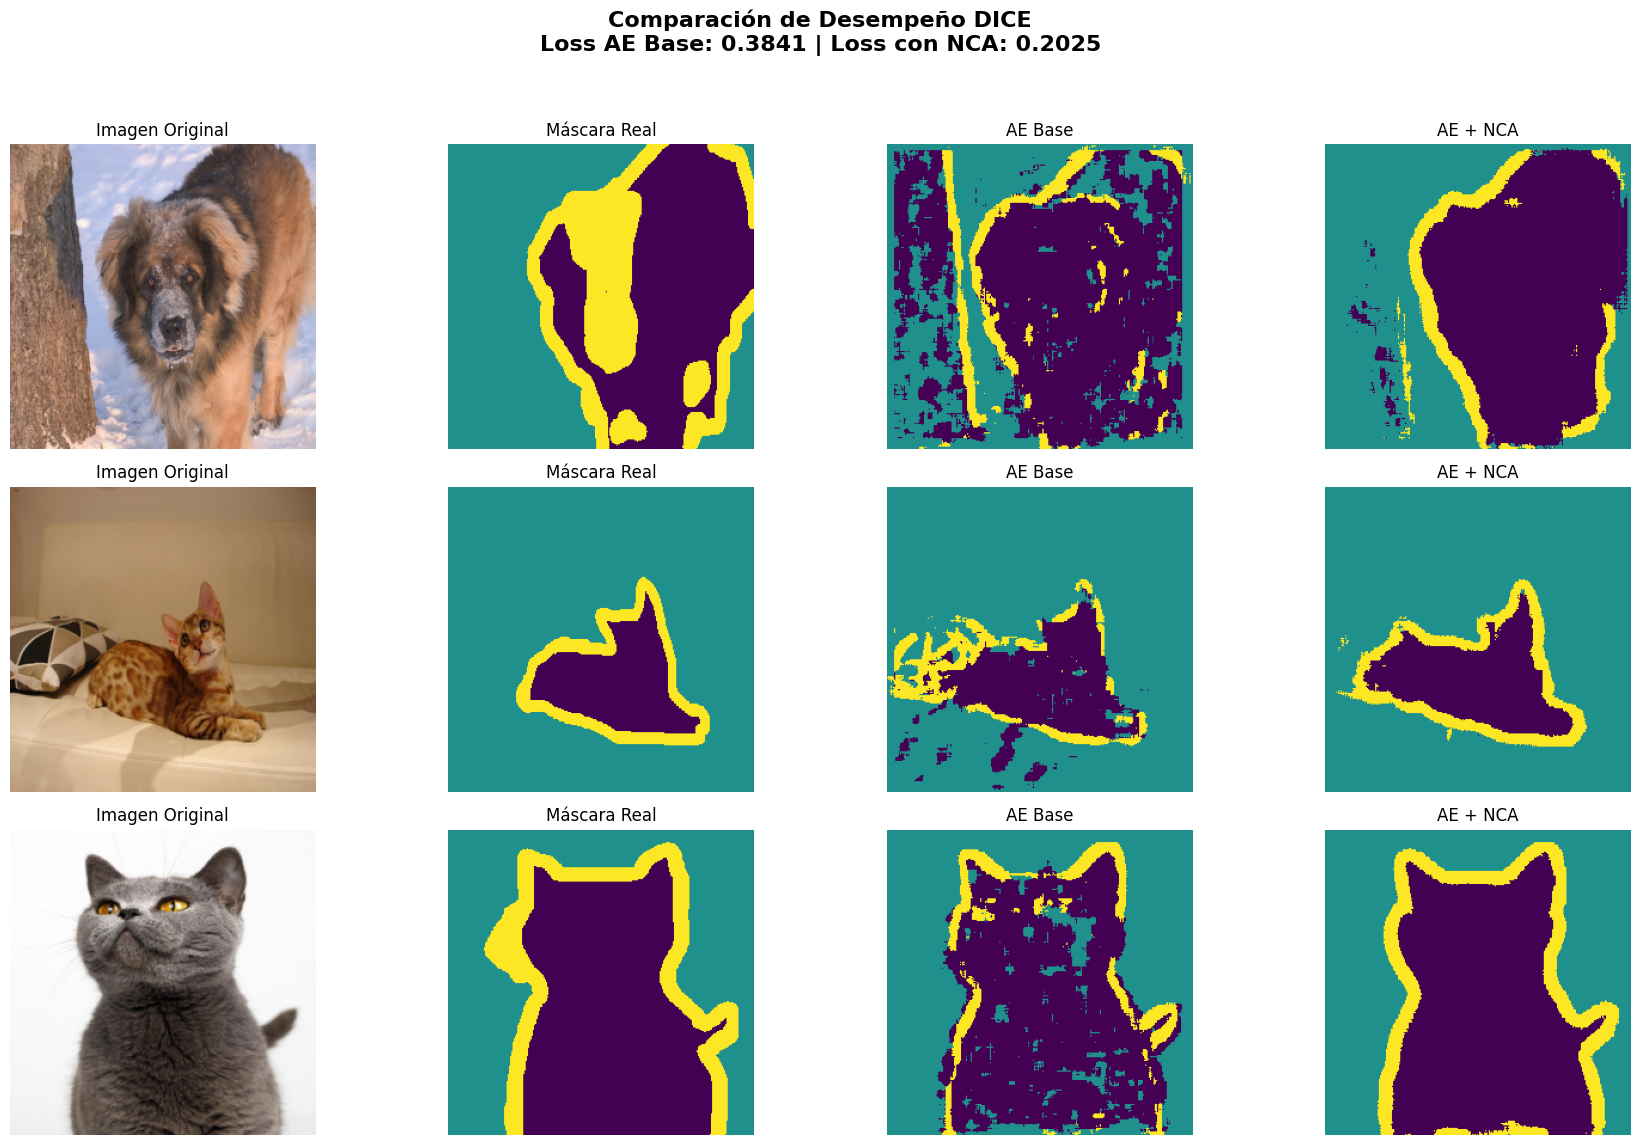

In [50]:
meta_nca.nca_steps = 64
comparar_modelos(meta_nca.ae, meta_nca, dog_test_loader, device)

### Coeficiente de Dice Multiclase Utilizado

Para evaluar el solapamiento global en todas las categorías de forma simultánea, se calcula el promedio simple sobre el conjunto de clases $C$:

$$\text{Dice Score} = \frac{1}{|C|} \sum_{c \in C} \frac{2 \sum_{i} p_{ic} g_{ic} + \epsilon}{\sum_{i} p_{ic}^2 + \sum_{i} g_{ic}^2 + \epsilon}$$

Donde la función de pérdida (**Dice Loss**) que el optimizador minimiza es el complemento a uno del puntaje:

$$\text{Dice Loss} = 1 - \text{Dice Score}$$

**Donde:**
* $|C|$: Número total de clases del trimapa ($|C| = 3$: Fondo, Contorno e Interior).
* $i$: Índice del píxel dentro de la grilla espacial $H \times W$.
* $p_{ic}$: Probabilidad predicha por el Decoder (vía Softmax) para el píxel $i$ en la clase $c$.
* $g_{ic}$: Valor binario real (*Ground Truth*) en formato One-Hot para el píxel $i$ en la clase $c$.
* $\epsilon$: Factor de suavizado numérico ($10^{-6}$) para prevenir divisiones por cero e indeterminaciones $\frac{0}{0}$.

# Pruebas:

## Style Transfer

Aca vemos si la transicion de una adn a otro, interpolamos estos con a través de una combinación convexa. Si la transición es "smooth" es indicio de que el espacio latente es cotinuo y convexo y que el parameter predictor no esta memorizando. 

In [30]:
# Instanciamos tu modelo completo 
metanca_model = models.MetaNCASegmenter(ae_params=params_encoder3, nca_steps=64).to(device)

# Cargamos los pesos definitivos de la Fase 2 que entrenaste anoche
metanca_model.load_state_dict(torch.load("metancav4.fase2_checkpoint_ep22.pth", map_location=device))

<All keys matched successfully>

🔮 Ejecutando transiciones moleculares en el autómata...


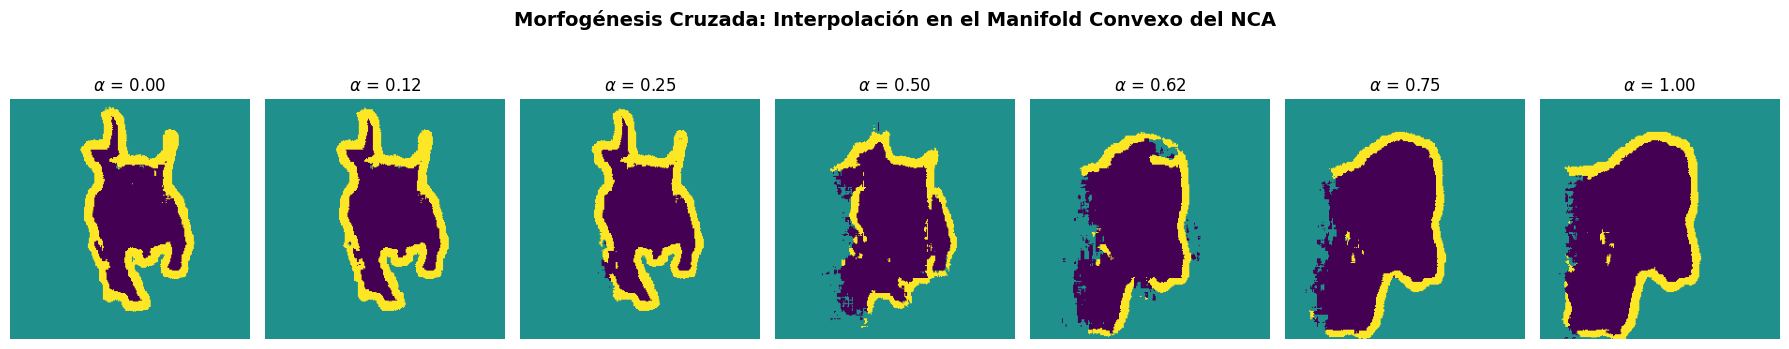

In [41]:
import numpy as np
import matplotlib.pyplot as plt

metanca_model.eval() 



# Tomamos un lote del test loader para elegir dos imágenes distintas
images_test, masks_test = next(iter(dog_test_loader))

img_A = images_test[0:1].to(device) 
img_B = images_test[1:2].to(device) 


# 3 EXTRACCIÓN DE SUS "ADN" GEOMÉTRICOS (Forward del Encoder congelado)
with torch.no_grad():
    # Mascota A
    c1_A = metanca_model.ae.conv_layer_1(img_A)
    c2_A = metanca_model.ae.conv_layer_2(c1_A)
    p2_A = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img_A))
    latent_A = metanca_model.ae.conv_layer_3(c2_A + p2_A)
    dna_A = latent_A.mean(dim=[2, 3]) # Vector de ADN (1, canales_latentes)

    # Mascota B
    c1_B = metanca_model.ae.conv_layer_1(img_B)
    c2_B = metanca_model.ae.conv_layer_2(c1_B)
    p2_B = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img_B))
    latent_B = metanca_model.ae.conv_layer_3(c2_B + p2_B)
    dna_B = latent_B.mean(dim=[2, 3])


#  INTERPOLACIÓN LATENTE Y SIMULACIÓN DEL NCA
# Definimos los pasos de alfa (de 0.0 que es 100% Mascota A, a 1.0 que es 100% Mascota B)
alphas = [0.0, 0.125, 0.25, 0.5, 0.625, 0.75, 1.0]
steps_evaluacion = 24 # Pasos fijos para que el autómata celular estabilice la forma

fig, axes = plt.subplots(1, len(alphas), figsize=(18, 4))
fig.suptitle("Morfogénesis Cruzada: Interpolación en el Manifold Convexo del NCA", fontsize=14, fontweight='bold')

print("🔮 Ejecutando transiciones moleculares en el autómata...")

for idx, alpha in enumerate(alphas):
    with torch.no_grad():
        # Interpolación lineal matemática en el espacio de fases
        dna_interp = (1.0 - alpha) * dna_A + alpha * dna_B
        latent_base_interp = (1.0 - alpha) * latent_A + alpha * latent_B
        c1_interp = (1.0 - alpha) * c1_A + alpha * c1_B
        
        # La HyperNetwork predice las nuevas leyes físicas para esta combinación híbrida
        dynamic_weights_interp = metanca_model.param_predictor(dna_interp)
        
        # El NCA evoluciona el estado latente mezclado usando las leyes mezcladas
        latent_evolved = metanca_model.nca(latent_base_interp, weights=dynamic_weights_interp, steps=steps_evaluacion)
        
        # El Decoder proyecta el resultado final al Trimapa
        d3_out = metanca_model.ae.trans_conv_3(latent_evolved)
        d2_out = metanca_model.ae.trans_conv_2(d3_out)
        mixed = metanca_model.ae.mix_layer(d2_out + c1_interp)
        outputs = metanca_model.ae.trans_conv_1(mixed)
        
        # Convertimos los logits del trimapa a clases (0, 1, 2) para visualizar
        pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu().numpy()
        
    # Graficamos en la celda de Jupyter
    ax = axes[idx]
    ax.imshow(pred_mask, cmap='viridis') # Puedes usar 'tab10' o tu mapa de color de trimapas
    ax.set_title(f"$\\alpha$ = {alpha:.2f}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Propiedad de Atractor

Veremos si logramos hacer que el parameter predictor forme NCAs estables. Cuyo estado final se comporta como un atractor al que se converge. i.e. no explota el estado si se aumentan las iteraciones indefinidamente.

🕵️‍♂️ Auditando la estabilidad del NCA a lo largo de 500 pasos...


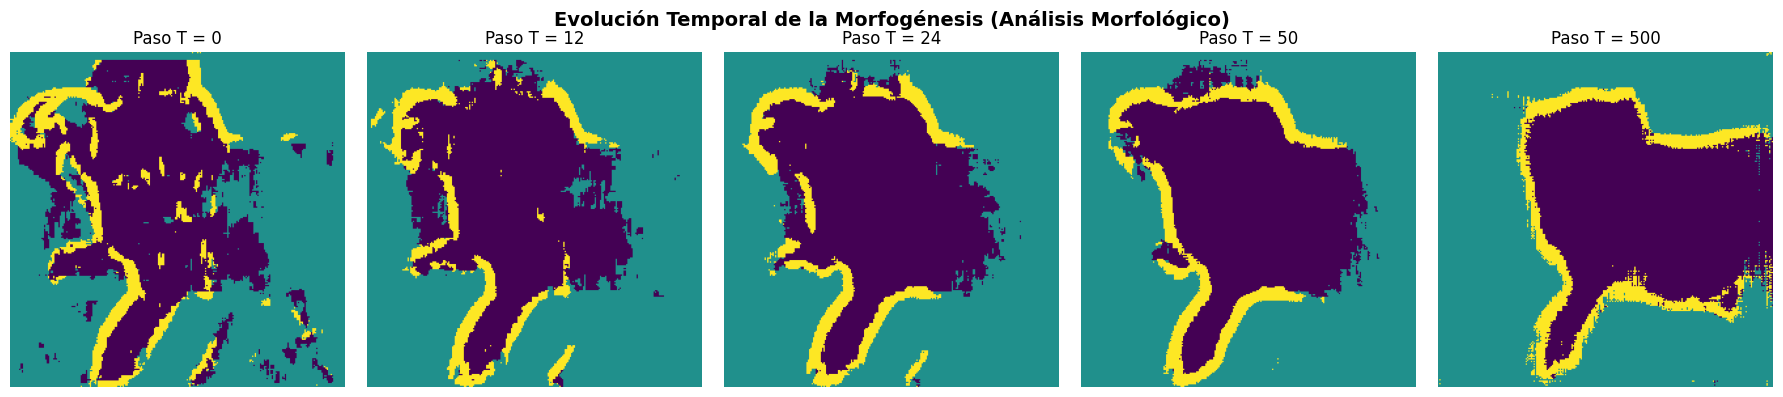

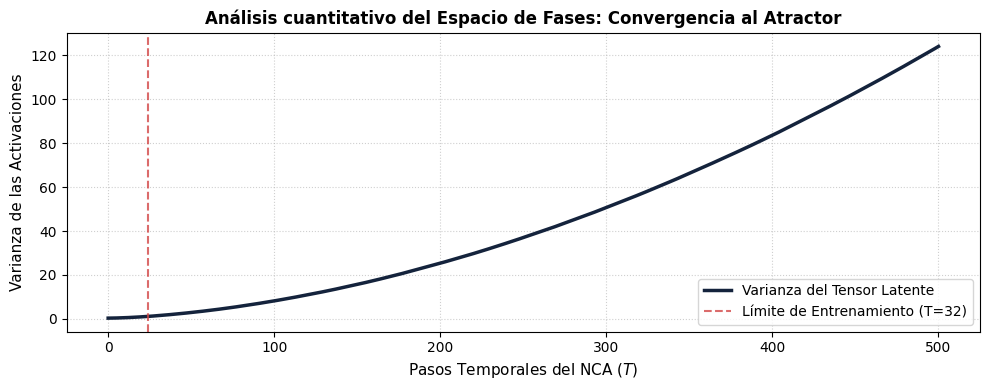

In [46]:

# Fijamos un horizonte temporal largo para buscar el atractor
HORIZONTE_TEMPORAL = 500
hitos_pasos = [0, 12, 24, 50, HORIZONTE_TEMPORAL]

# Tomamos una sola mascota de prueba del test loader
images_test, masks_test = next(iter(dog_test_loader))
img = images_test[0:1].to(device)
mask_target = masks_test[0:1].to(device)

# Listas para guardar las métricas de varianza y energía latente paso a paso
varianzas_latentes = []
pasos_eje_x = list(range(HORIZONTE_TEMPORAL + 1))

print(f"🕵️‍♂️ Auditando la estabilidad del NCA a lo largo de {HORIZONTE_TEMPORAL} pasos...")

# Diccionario para guardar las capturas visuales en los hitos seleccionados
capturas_visuales = {}

with torch.no_grad():
    # Paso A: Extraemos el estado latente inicial (Fase 1)
    c1_out = metanca_model.ae.conv_layer_1(img)
    c2_out = metanca_model.ae.conv_layer_2(c1_out)
    p2_out = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img))
    latent_base = metanca_model.ae.conv_layer_3(c2_out + p2_out)
    
    # Paso B: Predictor calcula las leyes físicas (pesos) a partir del ADN
    dna_vector = latent_base.mean(dim=[2, 3])
    dynamic_weights = metanca_model.param_predictor(dna_vector)
    
    # Paso C: Inicializamos el estado del autómata tal como lo hace el Pool
    # Clonamos el estado inicial para la simulación autoregresiva paso a paso
    estado_nca = latent_base.clone()
    
    # Registramos la varianza del paso 0
    varianzas_latentes.append(torch.var(estado_nca).item())
    
    # Capturamos el paso 0 proyectado por el decoder
    d3 = metanca_model.ae.trans_conv_3(estado_nca)
    d2 = metanca_model.ae.trans_conv_2(d3)
    mixed = metanca_model.ae.mix_layer(d2 + c1_out)
    out_inicial = torch.argmax(metanca_model.ae.trans_conv_1(mixed), dim=1).squeeze(0).cpu().numpy()
    capturas_visuales[0] = out_inicial

    # --- BUCLE TEMPORAL EXPLÍCITO PASO A PASO ---
    for t in range(1, HORIZONTE_TEMPORAL + 1):
        # Avanzamos el autómata un único paso de tiempo de forma recurrente
        estado_nca = metanca_model.nca(estado_nca, weights=dynamic_weights, steps=1)
        
        # Métrica Cuantitativa: Varianza del tensor latente para medir saturación o desintegración
        v_t = torch.var(estado_nca).item()
        varianzas_latentes.append(v_t)
        
        # Si estamos en un hito temporal, decodificamos y capturamos la máscara
        if t in hitos_pasos:
            d3 = metanca_model.ae.trans_conv_3(estado_nca)
            d2 = metanca_model.ae.trans_conv_2(d3)
            mixed = metanca_model.ae.mix_layer(d2 + c1_out)
            pred_mask = torch.argmax(metanca_model.ae.trans_conv_1(mixed), dim=1).squeeze(0).cpu().numpy()
            capturas_visuales[t] = pred_mask

# =====================================================================
# 2. PANEL VISUAL: EVOLUCIÓN TEMPORAL DE LA MÁSCARA
# =====================================================================
fig, axes = plt.subplots(1, len(hitos_pasos), figsize=(18, 4))
fig.suptitle("Evolución Temporal de la Morfogénesis (Análisis Morfológico)", fontsize=14, fontweight='bold')

for idx, t in enumerate(hitos_pasos):
    ax = axes[idx]
    ax.imshow(capturas_visuales[t], cmap='viridis')
    ax.set_title(f"Paso T = {t}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# =====================================================================
# 3. GRÁFICO DE DIAGNÓSTICO: VARIANZA DEL ESPACIO LATENTE (ATRACTOR)
# =====================================================================
plt.figure(figsize=(10, 4))
plt.plot(pasos_eje_x, varianzas_latentes, color='#14233c', linewidth=2.5, label='Varianza del Tensor Latente')

# Dibujamos una línea vertical indicando dónde terminó el entrenamiento teórico (ej: paso 24)
plt.axvline(x=24, color='#d24646', linestyle='--', alpha=0.8, label='Límite de Entrenamiento (T=32)')

plt.title("Análisis cuantitativo del Espacio de Fases: Convergencia al Atractor", fontsize=12, fontweight='bold')
plt.xlabel("Pasos Temporales del NCA ($T$)", fontsize=11)
plt.ylabel("Varianza de las Activaciones", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Robustez Morfogénica

Corre el codigo hasta el paso 10, aplica daño estocástico a través de una mascara de oclusión para ver capacidad regenerativa.

✂️ Iniciando experimento de Robustez Morfogénica...
Provocando amputación latente de 16x16 en el paso T = 10...


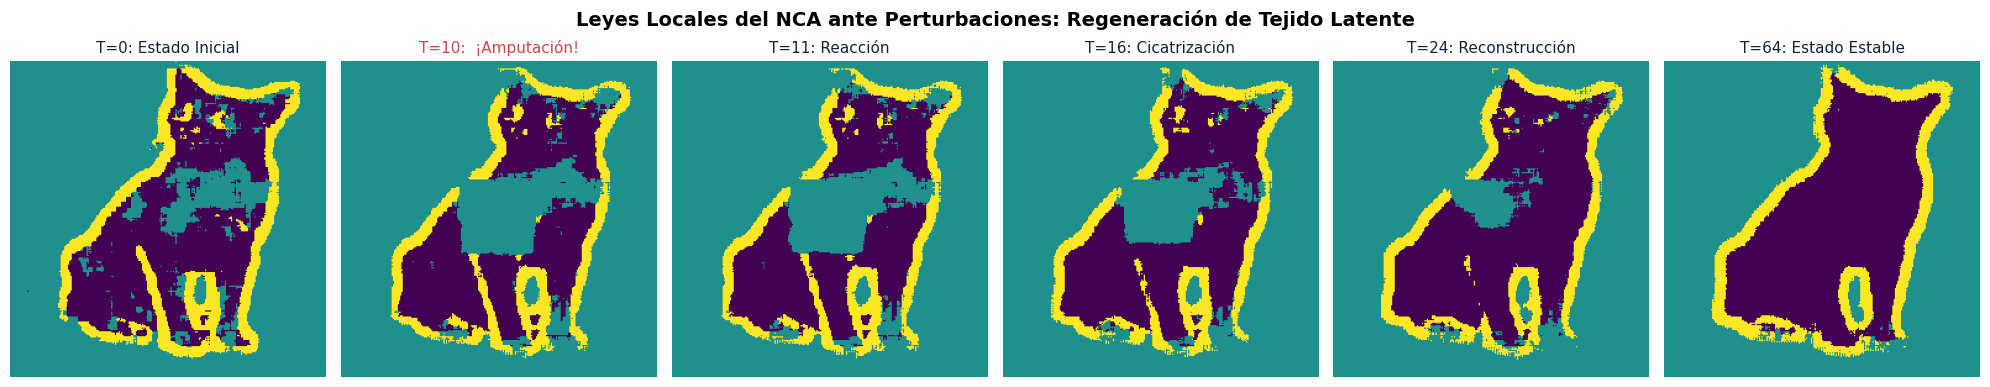

In [36]:
PASO_DEL_DAÑO = 10
PASOS_TOTALES = 64
TAMANO_HERIDA = 16 # Tamaño del cuadrado de amputación (en píxeles, de un mapa de 64x64)

# Tomamos una mascota de prueba del test loader
images_test, masks_test = next(iter(dog_test_loader))
img = images_test[0:1].to(device)

# Hitos temporales que vamos a capturar para el reporte visual
hitos_morfogenesis = [0, PASO_DEL_DAÑO, PASO_DEL_DAÑO + 1, 16, 24, PASOS_TOTALES]
capturas_trimapa = {}

print(f"✂️ Iniciando experimento de Robustez Morfogénica...")
print(f"Provocando amputación latente de {TAMANO_HERIDA}x{TAMANO_HERIDA} en el paso T = {PASO_DEL_DAÑO}...")

with torch.no_grad():
    # 1. Inicialización en la Fase 1
    c1_out = metanca_model.ae.conv_layer_1(img)
    c2_out = metanca_model.ae.conv_layer_2(c1_out)
    p2_out = metanca_model.ae.pass_through_2(metanca_model.ae.pass_through_1(img))
    latent_base = metanca_model.ae.conv_layer_3(c2_out + p2_out)
    
    # 2. HyperNetwork genera los pesos a partir del ADN
    dna_vector = latent_base.mean(dim=[2, 3])
    dynamic_weights = metanca_model.param_predictor(dna_vector)
    
    # Clonamos la base para la simulación
    estado_nca = latent_base.clone()
    
    # --- BUCLE DE EVOLUCIÓN CON INTERRUPCIÓN ---
    for t in range(0, PASOS_TOTALES + 1):
        
        # SI LLEGAMOS AL PASO DEL DAÑO: Amputamos el centro del espacio latente
        if t == PASO_DEL_DAÑO:
            # Calculamos las coordenadas del centro del mapa (64x64)
            _, _, h, w = estado_nca.shape
            centro_h, centro_w = h // 2, w // 2
            radio = TAMANO_HERIDA // 2
            
            # 💥 ACUCHILLAMOS EL ESPACIO LATENTE: Ponemos a 0 todos los canales en esa región
            estado_nca[:, :, centro_h - radio : centro_h + radio, centro_w - radio : centro_w + radio] = 0.0
            
        # Si estamos en un hito, decodificamos el estado actual para ver la máscara
        if t in hitos_morfogenesis:
            d3 = metanca_model.ae.trans_conv_3(estado_nca)
            d2 = metanca_model.ae.trans_conv_2(d3)
            mixed = metanca_model.ae.mix_layer(d2 + c1_out)
            pred_mask = torch.argmax(metanca_model.ae.trans_conv_1(mixed), dim=1).squeeze(0).cpu().numpy()
            capturas_trimapa[t] = pred_mask
            
        # Avanzamos el autómata 1 paso (excepto en el último paso)
        if t < PASOS_TOTALES:
            estado_nca = metanca_model.nca(estado_nca, weights=dynamic_weights, steps=1)

# =====================================================================
# 2. PANEL VISUAL DE LA REGENERACIÓN DEL TEJIDO
# =====================================================================
fig, axes = plt.subplots(1, len(hitos_morfogenesis), figsize=(20, 4))
fig.suptitle("Leyes Locales del NCA ante Perturbaciones: Regeneración de Tejido Latente", fontsize=14, fontweight='bold')

titulos = {
    0: "T=0: Estado Inicial",
    PASO_DEL_DAÑO: f"T={PASO_DEL_DAÑO}:  ¡Amputación!",
    PASO_DEL_DAÑO + 1: f"T={PASO_DEL_DAÑO+1}: Reacción",
    16: "T=16: Cicatrización",
    24: "T=24: Reconstrucción",
    PASOS_TOTALES: f"T={PASOS_TOTALES}: Estado Estable"
}

for idx, t in enumerate(hitos_morfogenesis):
    ax = axes[idx]
    ax.imshow(capturas_trimapa[t], cmap='viridis')
    ax.set_title(titulos[t], fontsize=11, color='#d24646' if "!" in titulos[t] else '#14233c')
    ax.axis('off')

plt.tight_layout()
plt.show()